# Text Generation with RNN
**Dataset:** Frankenstein (Project Gutenberg)  
**Framework:** PyTorch  
**Architecture:** Embedding → Elman RNN → Fully-Connected

## 1. Imports

In [12]:
import re
import random
import math
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


PyTorch version: 2.7.0+cu118
Device: cuda


## 2. Dataset Preparation

We scrape the raw HTML from Project Gutenberg, strip tags, tokenise into
lowercase words, build a vocabulary, and create sliding-window sequences.

| Variable | Value |
|----------|-------|
| `WINDOW_SIZE` | 100 |
| Input length | 99 tokens |
| Target | 1 token (next word) |

In [13]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
WINDOW_SIZE = 100        # input seq_len = 99, target = 1
VOCAB_CAP   = 5_000      # keep top-N words
URL = "https://www.gutenberg.org/cache/epub/84/pg84-images.html"

# ── 2.1  Fetch & clean text ──────────────────────────────────────────────────
print("Fetching Frankenstein …")
try:
    with urllib.request.urlopen(URL, timeout=30) as r:
        html = r.read().decode("utf-8", errors="ignore")
    text = re.sub(r"<[^>]+>", " ", html)
    text = re.sub(r"\s+", " ", text).strip()
    print(f"  Downloaded {len(text):,} characters")
except Exception as e:
    print(f"  Network error ({e}) – using fallback text")
    text = (
        "It was on a dreary night of November that I beheld the accomplishment "
        "of my toils. With an anxiety that almost amounted to agony, I collected "
        "the instruments of life around me that I might infuse a spark of being "
        "into the lifeless thing that lay at my feet. It was already one in the "
        "morning the rain pattered dismally against the panes and my candle was "
        "nearly burnt out when by the glimmer of the half-extinguished light I "
        "saw the dull yellow eye of the creature open it breathed hard and a "
        "convulsive motion agitated its limbs. How can I describe my emotions at "
        "this catastrophe or how delineate the wretch whom with such infinite "
        "pains and care I had endeavoured to form. His limbs were in proportion "
        "and I had selected his features as beautiful. Beautiful Great God His "
        "yellow skin scarcely covered the work of muscles and arteries beneath "
        "his hair was of a lustrous black and flowing his teeth of a pearly "
        "whiteness but these luxuriances only formed a more horrid contrast. "
    ) * 80

# ── 2.2  Tokenise ────────────────────────────────────────────────────────────
all_tokens = re.findall(r"[a-z']+", text.lower())
print(f"  Total tokens : {len(all_tokens):,}")


Fetching Frankenstein …
  Downloaded 439,999 characters
  Total tokens : 78,771


In [14]:
# ── 2.3  Vocabulary ──────────────────────────────────────────────────────────
freq      = Counter(all_tokens)
top_words = [w for w, _ in freq.most_common(VOCAB_CAP - 1)]
word2idx  = {"<UNK>": 0}
word2idx.update({w: i + 1 for i, w in enumerate(top_words)})
idx2word  = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f"  Vocabulary size : {VOCAB_SIZE}")


  Vocabulary size : 5000


In [15]:
# ── 2.4  Encode & build sliding-window sequences ─────────────────────────────
SEQ_LEN = WINDOW_SIZE - 1   # 99

encoded = [word2idx.get(t, 0) for t in all_tokens]

data    = [encoded[i : i + SEQ_LEN]  for i in range(len(encoded) - WINDOW_SIZE + 1)]
targets = [encoded[i + SEQ_LEN]      for i in range(len(encoded) - WINDOW_SIZE + 1)]

print(f"  Number of sequences : {len(data):,}")
print(f"  Input length        : {SEQ_LEN}")
print(f"  First input sample  : {data[0][:10]} …")
print(f"  First target        : {targets[0]}  ('{idx2word[targets[0]]}')")


  Number of sequences : 78,672
  Input length        : 99
  First input sample  : [490, 991, 1415, 490, 1242, 1415, 37, 2370, 1636, 2371] …
  First target        : 173  ('margin')


## 3. PyTorch Dataset & DataLoader

In [16]:
class TextDataset(Dataset):
    def __init__(self, seqs, tgts):
        self.X = torch.tensor(seqs, dtype=torch.long)
        self.y = torch.tensor(tgts, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH = 128
random.seed(42)
indices = list(range(len(data))); random.shuffle(indices)
split   = int(0.9 * len(indices))

train_ds = TextDataset([data[i] for i in indices[:split]],
                       [targets[i] for i in indices[:split]])
val_ds   = TextDataset([data[i] for i in indices[split:]],
                       [targets[i] for i in indices[split:]])

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, drop_last=False)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")


Train batches : 553
Val   batches : 62


## 4. RNN Model

```
Input (B, 99)  →  Embedding (B, 99, 64)
               →  RNN       (B, 99, 256)
               →  last step (B, 256)
               →  FC        (B, vocab_size)
```

In [17]:
class TextRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn   = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, nonlinearity="tanh")
        self.fc    = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h=None):
        emb        = self.embed(x)           # (B, T, E)
        out, h_new = self.rnn(emb, h)        # (B, T, H)
        logits     = self.fc(out[:, -1, :])  # last timestep → (B, V)
        return logits, h_new

device = "cuda" if torch.cuda.is_available() else "cpu"

EMBED_DIM  = 64
HIDDEN_DIM = 256

model = TextRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")


TextRNN(
  (embed): Embedding(5000, 64, padding_idx=0)
  (rnn): RNN(64, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=5000, bias=True)
)

Total parameters: 1,687,432


## 5. Training

In [18]:
LR     = 1e-3
EPOCHS = 30
CLIP   = 5.0

criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=2, gamma=0.5)

train_losses, val_perplexities = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────
    model.train()
    running = 0.0
    for step, (xb, yb) in enumerate(train_loader):
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimiser.step()
        running += loss.item()
        if (step + 1) % 300 == 0:
            print(f"  Epoch {epoch} | step {step+1:>5}/{len(train_loader)}"
                  f" | loss {running/(step+1):.4f}")

    avg_train = running / len(train_loader)
    train_losses.append(avg_train)

    # ── Validate ─────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            val_loss += criterion(logits, yb).item()
    ppl = math.exp(val_loss / len(val_loader))
    val_perplexities.append(ppl)

    print(f"\n{'─'*60}")
    print(f"Epoch {epoch}  |  train_loss {avg_train:.4f}  |  val_perplexity {ppl:.2f}")
    print(f"{'─'*60}\n")
    scheduler.step()


  Epoch 1 | step   300/553 | loss 6.4211

────────────────────────────────────────────────────────────
Epoch 1  |  train_loss 6.2032  |  val_perplexity 350.26
────────────────────────────────────────────────────────────

  Epoch 2 | step   300/553 | loss 5.5096

────────────────────────────────────────────────────────────
Epoch 2  |  train_loss 5.4885  |  val_perplexity 290.18
────────────────────────────────────────────────────────────

  Epoch 3 | step   300/553 | loss 5.0005

────────────────────────────────────────────────────────────
Epoch 3  |  train_loss 4.9976  |  val_perplexity 271.97
────────────────────────────────────────────────────────────

  Epoch 4 | step   300/553 | loss 4.7416

────────────────────────────────────────────────────────────
Epoch 4  |  train_loss 4.7595  |  val_perplexity 269.84
────────────────────────────────────────────────────────────

  Epoch 5 | step   300/553 | loss 4.4648

────────────────────────────────────────────────────────────
Epoch 5  |  t

## 6. Training Curves

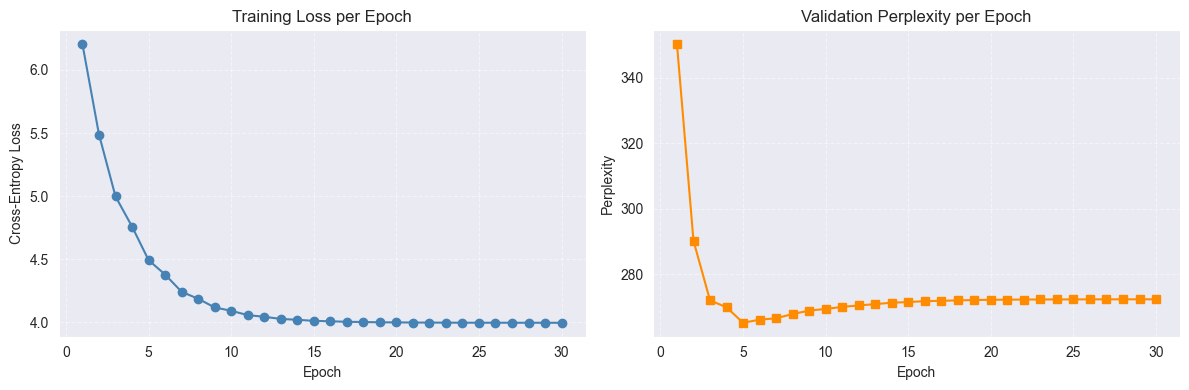

Saved training_curves.png


In [19]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_losses, marker='o', color='steelblue')
ax1.set_title("Training Loss per Epoch")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(range(1, EPOCHS+1), val_perplexities, marker='s', color='darkorange')
ax2.set_title("Validation Perplexity per Epoch")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Perplexity")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()
print("Saved training_curves.png")


## 7. Text Generation

We use **temperature-scaled sampling** (T = 0.8):

> $p_i = \\frac{e^{z_i / T}}{\\sum_j e^{z_j / T}}$

Lower temperature → more conservative; higher → more creative.

In [20]:
def generate(seed_phrase: str, num_words: int = 120, temperature: float = 0.8) -> str:
    model.eval()
    seed_tokens = re.findall(r"[a-z']+", seed_phrase.lower())
    current     = [word2idx.get(t, 0) for t in seed_tokens]

    # Pad / trim to SEQ_LEN
    if len(current) < SEQ_LEN:
        current = [0] * (SEQ_LEN - len(current)) + current
    else:
        current = current[-SEQ_LEN:]

    result = list(seed_tokens)
    with torch.no_grad():
        for _ in range(num_words):
            x         = torch.tensor([current], dtype=torch.long, device=device)
            logits, _ = model(x)
            probs     = torch.softmax(logits[0] / temperature, dim=-1)
            next_i    = torch.multinomial(probs, 1).item()
            result.append(idx2word.get(next_i, "<UNK>"))
            current   = current[1:] + [next_i]

    return " ".join(result)


In [21]:
seed = "it was a dark and stormy night when the creature appeared"
print(f"Seed: '{seed}'\n")
print("─" * 65)
print(generate(seed, num_words=120, temperature=0.8))
print("─" * 65)


Seed: 'it was a dark and stormy night when the creature appeared'

─────────────────────────────────────────────────────────────────
it was a dark and stormy night when the creature appeared in natural philosophy family was for ever before was again by a mixture of its family your father was the five making by a slight various <UNK> to pay my feelings on this <UNK> and the sun rose his soul until this filthy the neighbourhood of its departure the foundation the glacier of impending disaster guardians and unknown the foundation the inaccessible stimulus which i had know <UNK> to me in the cabin i quitted the world and the forms of this poor girl who could you would curse my <UNK> years you may i am while the <UNK> of the <UNK> where i had yet on my attention from it was no father had already been in what i
─────────────────────────────────────────────────────────────────


In [22]:
# Generate with different temperatures to compare
for temp in [0.5, 0.8, 1.2]:
    print(f"\n── Temperature = {temp} ──────────────────────────────────────")
    print(generate("the monster walked through the dark forest", num_words=40, temperature=temp))



── Temperature = 0.5 ──────────────────────────────────────
the monster walked through the dark forest of <UNK> project gutenberg works and <UNK> or <UNK> or <UNK> or any project gutenberg license any other project gutenberg electronic work and the project gutenberg concept are not protected and you if you are located to me and you

── Temperature = 0.8 ──────────────────────────────────────
the monster walked through the dark forest of terms or are rustic not protected this work or any letter that i should have been depended and the sullen of the crime i pass a solitude alive towards it were <UNK> in a branches and i found the

── Temperature = 1.2 ──────────────────────────────────────
the monster walked through the dark forest among despondency but for particular sudden became header <UNK> she in m occurrence i hired developed turned to the kitchen to seemed in the exile clouds connected return soon i truly nothing it descends she of the heavenly among <UNK>
